In [56]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [57]:
DATA_PATH = Path('input_data.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('../input_data.csv')

MODELS_DIR = Path('models')
if not MODELS_DIR.exists():
    MODELS_DIR = Path('../models')

MODELS_DIR.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError('Не найден файл input_data.csv')

DATA_PATH


PosixPath('../input_data.csv')

In [58]:
# читаем датасет частями и берем случайную выборку
chunk_size = 250_000  # сколько строк читаем за один раз
sample_part = 0.08  # берем примерно 8% строк
max_rows = 900_000  # максимум строк для обучения
random_seed = 42  # чтобы выборка повторялась одинаково
test_size = 0.2  # 20% данных оставим для теста

rng = np.random.default_rng(random_seed)
parts = []  # сюда складываем куски таблицы

for chunk in pd.read_csv(DATA_PATH, sep=';', chunksize=chunk_size):  # читаем файл частями
    sample_mask = rng.random(len(chunk)) < sample_part  # случайно выбираем часть строк
    parts.append(chunk.loc[sample_mask].copy())  # добавляем выбранные строки

    rows_now = sum(len(part) for part in parts)  # считаем, сколько строк уже набрали
    print('строк в выборке:', rows_now)

    if rows_now >= max_rows:  # останавливаемся, если строк уже достаточно
        break

df = pd.concat(parts, ignore_index=True)  # объединяем все части в одну таблицу

if len(df) > max_rows:
    df = df.sample(max_rows, random_state=random_seed).reset_index(drop=True)  # оставляем ровно max_rows строк

print('размер таблицы:', df.shape)
df.head()

строк в выборке: 19873
строк в выборке: 39916
строк в выборке: 59816
строк в выборке: 79789
строк в выборке: 99489
строк в выборке: 119436
строк в выборке: 139447
строк в выборке: 159421
строк в выборке: 179457
строк в выборке: 199312
строк в выборке: 219326
строк в выборке: 239544
строк в выборке: 259603
строк в выборке: 279685
строк в выборке: 299784
строк в выборке: 319822
строк в выборке: 339773
строк в выборке: 359653
строк в выборке: 379700
строк в выборке: 399593
строк в выборке: 419753
строк в выборке: 439446
строк в выборке: 459370
строк в выборке: 479228
строк в выборке: 498993
строк в выборке: 519194
строк в выборке: 539335
строк в выборке: 559343
строк в выборке: 579402
строк в выборке: 599384
строк в выборке: 619246
строк в выборке: 639478
строк в выборке: 659295
строк в выборке: 679091
строк в выборке: 699176
строк в выборке: 719147
строк в выборке: 739251
строк в выборке: 759263
строк в выборке: 779408
строк в выборке: 799524
строк в выборке: 819474
строк в выборке: 8396

,date,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id
0,2021-10-27,4489900,8,17,3,76.1,0.0,51.763657,39.182927,0,2,394066.0,280400.0,36,1908892.0
1,2021-11-27,5500000,1,5,2,57.0,12.0,53.743003,91.414853,0,0,655016.0,127920.0,19,729157.0
2,2021-01-27,9081840,10,12,-1,31.6,6.8,43.585455,39.723155,0,2,354340.0,254038.0,23,752369.0
3,2021-07-11,13600000,3,3,4,99.0,7.3,44.599007,33.521162,4,0,299011.0,180394.0,92,1490324.0
4,2021-04-29,3600000,7,10,1,43.8,0.0,54.744435,20.533817,0,0,236029.0,NaN,39,NaN


In [59]:
print(df.shape)
print(df.columns.tolist())
df.head()

(900000, 15)
['date', 'price', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 'geo_lat', 'geo_lon', 'building_type', 'object_type', 'postal_code', 'street_id', 'id_region', 'house_id']


,date,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id
0,2021-10-27,4489900,8,17,3,76.1,0.0,51.763657,39.182927,0,2,394066.0,280400.0,36,1908892.0
1,2021-11-27,5500000,1,5,2,57.0,12.0,53.743003,91.414853,0,0,655016.0,127920.0,19,729157.0
2,2021-01-27,9081840,10,12,-1,31.6,6.8,43.585455,39.723155,0,2,354340.0,254038.0,23,752369.0
3,2021-07-11,13600000,3,3,4,99.0,7.3,44.599007,33.521162,4,0,299011.0,180394.0,92,1490324.0
4,2021-04-29,3600000,7,10,1,43.8,0.0,54.744435,20.533817,0,0,236029.0,NaN,39,NaN


In [60]:
# считаем пропуски по всем колонкам
missing = pd.DataFrame({
    'column': df.columns,
    'empty_count': df.isna().sum().values,
    'empty_percent': (df.isna().mean().values * 100).round(2),
    'type': df.dtypes.astype(str).values,
})

missing.sort_values('empty_percent', ascending=False)

,column,empty_count,empty_percent,type
12,street_id,333313,37.03,float64
14,house_id,258348,28.71,float64
11,postal_code,40156,4.46,float64
0,date,0,0.00,str
1,price,0,0.00,int64
2,level,0,0.00,int64
3,levels,0,0.00,int64
4,rooms,0,0.00,int64
5,area,0,0.00,float64
6,kitchen_area,0,0.00,float64


In [61]:
# приводим нужные поля к числовому типу
num_cols = [
    'price', 'level', 'levels', 'rooms', 'area', 'kitchen_area',
    'geo_lat', 'geo_lon', 'building_type', 'object_type',
    'postal_code', 'id_region',
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# из даты оставляем год и месяц объявления
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year.fillna(2021).astype(int)
df['month'] = df['date'].dt.month.fillna(1).astype(int)

df[['price', 'area', 'rooms', 'level', 'levels', 'kitchen_area']].describe().T

,count,mean,std,min,25%,50%,75%,max
price,900000.0,6.670049e+06,3.848331e+07,0.0,2600000.00,3994485.0,6500000.0,9.000000e+09
area,900000.0,5.314200e+01,2.722694e+01,1.4,36.47,46.7,63.0,4.990000e+02
rooms,900000.0,1.720277e+00,1.159537e+00,-1.0,1.00,2.0,2.0,9.000000e+00
level,900000.0,6.428208e+00,5.278176e+00,0.0,2.00,5.0,9.0,5.000000e+01
levels,900000.0,1.175965e+01,7.218852e+00,0.0,5.00,10.0,17.0,5.000000e+01
kitchen_area,900000.0,-2.665738e+00,3.243690e+01,-100.0,0.00,6.5,10.5,2.060000e+02


In [62]:
# убираем выбросы
before = len(df)

df = df.dropna(subset=['price', 'area', 'level', 'levels', 'rooms', 'geo_lat', 'geo_lon', 'id_region'])

df = df[df['price'].between(300_000, 80_000_000)]
df = df[df['area'].between(10, 250)]
df = df[df['level'].between(1, 80)]
df = df[df['levels'].between(1, 80)]
df = df[df['level'] <= df['levels']]
df = df[df['rooms'].between(-1, 6)]
df = df[df['geo_lat'].between(40, 75)]
df = df[df['geo_lon'].between(15, 185)]

df['rooms'] = df['rooms'].replace(-1, 0)  # в датасете студии обозначены как -1

bad_kitchen = (df['kitchen_area'] < 0) | (df['kitchen_area'] > df['area'] * 0.7)
df.loc[bad_kitchen, 'kitchen_area'] = np.nan
df['kitchen_area'] = df['kitchen_area'].fillna((df['area'] * 0.16).clip(5, 20))

price_per_meter = df['price'] / df['area']
low_border = price_per_meter.quantile(0.005)
high_border = price_per_meter.quantile(0.995)
df = df[price_per_meter.between(low_border, high_border)]

print('было:', before)
print('стало:', len(df))
print('удалили:', before - len(df))

было: 900000
стало: 884957
удалили: 15043


In [63]:
# создаем дополнительные признаки для модели
df['floor_ratio'] = df['level'] / df['levels']  # положение этажа относительно всего дома
df['is_first_floor'] = (df['level'] == 1).astype(int)  # 1, если квартира на первом этаже
df['is_last_floor'] = (df['level'] == df['levels']).astype(int)  # 1, если квартира на последнем этаже
df['area_per_room'] = df['area'] / df['rooms'].replace(0, 1)  # площадь на одну комнату
df['kitchen_ratio'] = df['kitchen_area'] / df['area']  # доля кухни от общей площади
df['log_area'] = np.log1p(df['area'])  # логарифм площади, чтобы сгладить большие значения
df['lat_round'] = df['geo_lat'].round(1).astype(int)  # примерная широта
df['lon_round'] = df['geo_lon'].round(1).astype(int)  # примерная долгота

cat_features = [
    'building_type', 'object_type', 'id_region',
    'postal_code', 'lat_round', 'lon_round', 'month',
]

num_features = [
    'area', 'kitchen_area', 'level', 'levels', 'rooms',
    'geo_lat', 'geo_lon', 'year', 'floor_ratio',
    'is_first_floor', 'is_last_floor', 'area_per_room',
    'kitchen_ratio', 'log_area',
]

features = num_features + cat_features

for col in cat_features:
    df[col] = df[col].fillna(-1).astype(str)

for col in num_features:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    df[col] = df[col].fillna(df[col].median())

print('признаков:', len(features))
features

признаков: 21


['area',
 'kitchen_area',
 'level',
 'levels',
 'rooms',
 'geo_lat',
 'geo_lon',
 'year',
 'floor_ratio',
 'is_first_floor',
 'is_last_floor',
 'area_per_room',
 'kitchen_ratio',
 'log_area',
 'building_type',
 'object_type',
 'id_region',
 'postal_code',
 'lat_round',
 'lon_round',
 'month']

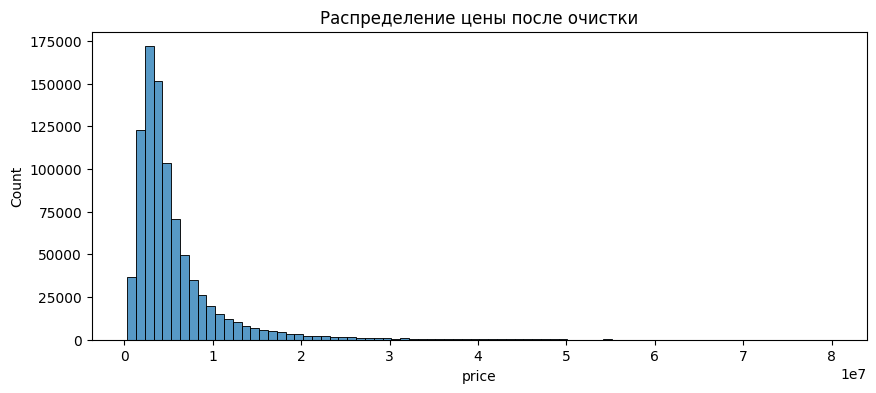

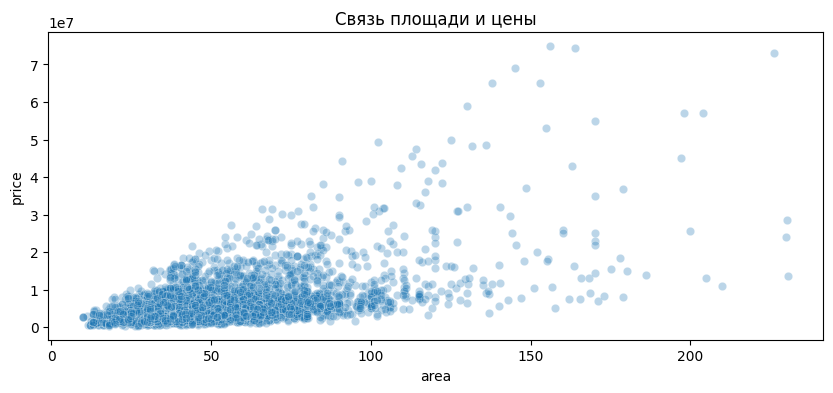

In [64]:
plt.figure(figsize=(10, 4))
sns.histplot(df['price'], bins=80)
plt.title('Распределение цены после очистки')
plt.show()

plt.figure(figsize=(10, 4))
sns.scatterplot(data=df.sample(min(5000, len(df)), random_state=random_seed), x='area', y='price', alpha=0.3)
plt.title('Связь площади и цены')
plt.show()

In [65]:
# делим данные на обучающую и тестовую части
X = df[features].copy()
y = np.log1p(df['price'])  # логарифмирование стабилизирует разброс цен

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_seed)

cat_indexes = [X.columns.get_loc(col) for col in cat_features]

print('train:', X_train.shape)
print('test:', X_test.shape)

train: (707965, 21)
test: (176992, 21)


Часть данных оставляю для теста, чтобы оценить модель на квартирах, которые она не видела при обучении.

In [66]:
# обучаем основную модель CatBoost
model = CatBoostRegressor(
    iterations=1400,  # максимальное количество деревьев
    learning_rate=0.06,  # скорость обучения модели
    depth=9,  # глубина деревьев
    l2_leaf_reg=5,  # регуляризация, чтобы модель меньше переобучалась
    loss_function='RMSE',  # функция ошибки для обучения
    eval_metric='RMSE',  # метрика для проверки качества
    random_seed=random_seed,  # фиксируем случайность
    early_stopping_rounds=100,  # остановка, если качество долго не улучшается
    verbose=100,  # выводить прогресс каждые 100 итераций
)

model.fit(
    X_train,  # признаки для обучения
    y_train,  # правильные ответы для обучения
    cat_features=cat_indexes,  # номера категориальных признаков
    eval_set=(X_test, y_test),  # данные для проверки модели
    use_best_model=True,  # оставить лучшую версию модели
)

0:	learn: 0.6938742	test: 0.6910286	best: 0.6910286 (0)	total: 173ms	remaining: 4m 2s
100:	learn: 0.2361277	test: 0.2308178	best: 0.2308178 (100)	total: 11.5s	remaining: 2m 27s
200:	learn: 0.2218629	test: 0.2172110	best: 0.2172110 (200)	total: 23.9s	remaining: 2m 22s
300:	learn: 0.2146030	test: 0.2106188	best: 0.2106188 (300)	total: 36.7s	remaining: 2m 13s
400:	learn: 0.2094151	test: 0.2060548	best: 0.2060548 (400)	total: 49.9s	remaining: 2m 4s
500:	learn: 0.2054778	test: 0.2026058	best: 0.2026058 (500)	total: 1m 3s	remaining: 1m 53s
600:	learn: 0.2023587	test: 0.2000463	best: 0.2000463 (600)	total: 1m 16s	remaining: 1m 41s
700:	learn: 0.1997115	test: 0.1979880	best: 0.1979880 (700)	total: 1m 29s	remaining: 1m 29s
800:	learn: 0.1974405	test: 0.1961839	best: 0.1961839 (800)	total: 1m 43s	remaining: 1m 17s
900:	learn: 0.1954403	test: 0.1946857	best: 0.1946857 (900)	total: 1m 58s	remaining: 1m 5s
1000:	learn: 0.1936499	test: 0.1933721	best: 0.1933721 (1000)	total: 2m 12s	remaining: 52.7s


CatBoostRegressor(depth=9, early_stopping_rounds=100, eval_metric='RMSE', iterations=1400, l2_leaf_reg=5, learning_rate=0.06, loss_function='RMSE', random_seed=42, verbose=100)

CatBoost выбран потому, что хорошо работает с табличными данными и умеет обрабатывать категориальные признаки без ручного one-hot encoding

In [67]:
# считаем метрики в рублях и возвращаемся из логарифма к обычной цене
def count_metrics(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return {
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4),
        'MAPE_percent': round(mape, 4),
    }

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_metrics = count_metrics(y_train, train_pred)
test_metrics = count_metrics(y_test, test_pred)

pd.DataFrame([train_metrics, test_metrics], index=['train', 'test'])

,MAE,RMSE,R2,MAPE_percent
train,765240.7917,1.690548e+06,0.9129,13.6326
test,780781.4763,1.756825e+06,0.9058,13.8856


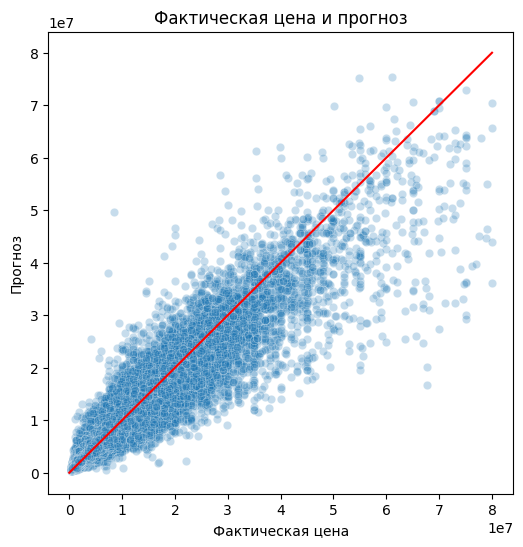

In [68]:
# сравниваем фактические цены и прогноз модели
y_real = np.expm1(y_test)
y_pred = np.expm1(test_pred)

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_real, y=y_pred, alpha=0.25)
limit = max(y_real.max(), y_pred.max())
plt.plot([0, limit], [0, limit], color='red')
plt.title('Фактическая цена и прогноз')
plt.xlabel('Фактическая цена')
plt.ylabel('Прогноз')
plt.show()

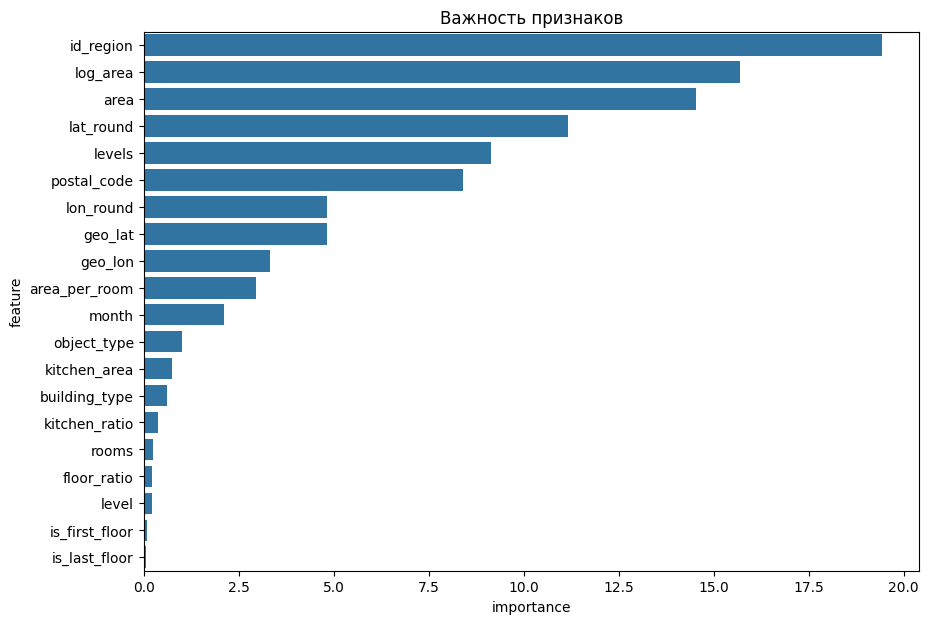

,feature,importance
16,id_region,19.427127
13,log_area,15.690563
0,area,14.541319
18,lat_round,11.177470
3,levels,9.144943
17,postal_code,8.401200
19,lon_round,4.833817
5,geo_lat,4.822874
6,geo_lon,3.323158
11,area_per_room,2.951825


In [69]:
# какие признаки сильнее всего влияют на прогноз
importance = pd.DataFrame({
    'feature': features,
    'importance': model.get_feature_importance(),
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance.head(20), x='importance', y='feature')
plt.title('Важность признаков')
plt.show()

importance.head(20)

In [70]:
# обучаем две дополнительные модели для нижней и верхней границы цены
low_alpha = 0.15
high_alpha = 0.85

model_low = CatBoostRegressor(
    iterations=900,
    learning_rate=0.06,
    depth=8,
    l2_leaf_reg=5,
    loss_function=f'Quantile:alpha={low_alpha}',
    eval_metric=f'Quantile:alpha={low_alpha}',
    random_seed=43,
    early_stopping_rounds=80,
    verbose=100,
)

model_high = CatBoostRegressor(
    iterations=900,
    learning_rate=0.06,
    depth=8,
    l2_leaf_reg=5,
    loss_function=f'Quantile:alpha={high_alpha}',
    eval_metric=f'Quantile:alpha={high_alpha}',
    random_seed=44,
    early_stopping_rounds=80,
    verbose=100,
)

model_low.fit(X_train, y_train, cat_features=cat_indexes, eval_set=(X_test, y_test), use_best_model=True)
model_high.fit(X_train, y_train, cat_features=cat_indexes, eval_set=(X_test, y_test), use_best_model=True)

0:	learn: 0.1527922	test: 0.1519205	best: 0.1519205 (0)	total: 174ms	remaining: 2m 36s
100:	learn: 0.0541428	test: 0.0527971	best: 0.0527971 (100)	total: 12.8s	remaining: 1m 41s
200:	learn: 0.0503255	test: 0.0491070	best: 0.0491070 (200)	total: 26.5s	remaining: 1m 32s
300:	learn: 0.0482909	test: 0.0471539	best: 0.0471539 (300)	total: 40.6s	remaining: 1m 20s
400:	learn: 0.0468808	test: 0.0458783	best: 0.0458783 (400)	total: 54.2s	remaining: 1m 7s
500:	learn: 0.0458911	test: 0.0450005	best: 0.0450005 (500)	total: 1m 7s	remaining: 54s
600:	learn: 0.0451449	test: 0.0443502	best: 0.0443502 (600)	total: 1m 21s	remaining: 40.5s
700:	learn: 0.0444720	test: 0.0437972	best: 0.0437972 (700)	total: 1m 35s	remaining: 27.1s
800:	learn: 0.0439088	test: 0.0433449	best: 0.0433449 (800)	total: 1m 50s	remaining: 13.7s
899:	learn: 0.0434287	test: 0.0429554	best: 0.0429554 (899)	total: 2m 4s	remaining: 0us

bestTest = 0.04295540794
bestIteration = 899

0:	learn: 0.1735171	test: 0.1732494	best: 0.1732494 (0

CatBoostRegressor(depth=8, early_stopping_rounds=80, eval_metric='Quantile:alpha=0.85', iterations=900, l2_leaf_reg=5, learning_rate=0.06, loss_function='Quantile:alpha=0.85', random_seed=44, verbose=100)

In [71]:
# как часто реальная цена попадает в рассчитанный интервал
low_pred = np.expm1(model_low.predict(X_test))
high_pred = np.expm1(model_high.predict(X_test))
real_price = np.expm1(y_test)

low_pred, high_pred = np.minimum(low_pred, high_pred), np.maximum(low_pred, high_pred)
interval_coverage = ((real_price >= low_pred) & (real_price <= high_pred)).mean() * 100
avg_interval_width = np.mean(high_pred - low_pred)

print('попадание в интервал %:', round(interval_coverage, 2))
print('средняя ширина интервала:', round(avg_interval_width, 0))

попадание в интервал %: 68.84
средняя ширина интервала: 2036171.0


In [72]:
model_path = MODELS_DIR / 'input_catboost_model.cbm'
model_low_path = MODELS_DIR / 'input_catboost_low.cbm'
model_high_path = MODELS_DIR / 'input_catboost_high.cbm'

model.save_model(model_path)
model_low.save_model(model_low_path)
model_high.save_model(model_high_path)

print('сохранили основную модель:', model_path)
print('сохранили нижнюю границу:', model_low_path)
print('сохранили верхнюю границу:', model_high_path)

сохранили основную модель: ../models/input_catboost_model.cbm
сохранили нижнюю границу: ../models/input_catboost_low.cbm
сохранили верхнюю границу: ../models/input_catboost_high.cbm
